## 1. 라이브러리 임포트

In [3]:
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

%matplotlib inline
shap.initjs()

## 2. 데이터 로드

In [4]:
datasets = pd.read_csv('heart.csv')

### 데이터 특성 설명
| 특성 | 설명 |
|---|---|
| Age | 나이 |
| Sex | 성별 (M/F) |
| ChestPainType | 흉통 유형 (TA: 전형적 협심증, ATA: 비전형적, NAP: 비협심증성, ASY: 무증상) |
| RestingBP | 안정 시 혈압 |
| Cholesterol | 콜레스테롤 |
| FastingBS | 공복 혈당 (1: >120mg/dl, 0: ≤120mg/dl) |
| RestingECG | 안정 시 심전도 결과 |
| MaxHR | 최대 심박수 |
| ExerciseAngina | 운동 시 협심증 (Y/N) |
| Oldpeak | 운동 유발 ST 강하 |
| ST_Slope | ST 분절 기울기 |
| HeartDisease | 타겟 (0: 정상, 1: 심장질환) |

## 3. 데이터 확인

In [5]:
# 결측치 확인
datasets.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [6]:
"""
콜레스테롤 데이터가 0인 경우가 있어서 이 경우를 중앙값으로 대체
"""
datasets['Cholesterol'] = datasets['Cholesterol'].replace(0, np.nan)
datasets['Cholesterol'] = datasets['Cholesterol'].fillna(datasets['Cholesterol'].median())

In [7]:
datasets.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0


In [8]:
# 가슴 통증 유형 종류 확인
datasets['ChestPainType'].unique()

array(['ATA', 'NAP', 'ASY', 'TA'], dtype=object)

In [9]:
datasets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    float64
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 86.2+ KB


## 4. 탐색적 데이터 분석 (EDA)

- Age : 50대 ~ 60대 초반까지의 분포 높음
- Sex : 남자가 여자보다 월등히 많음
- ChestPainType : 가슴 통증 유형 간 불균형

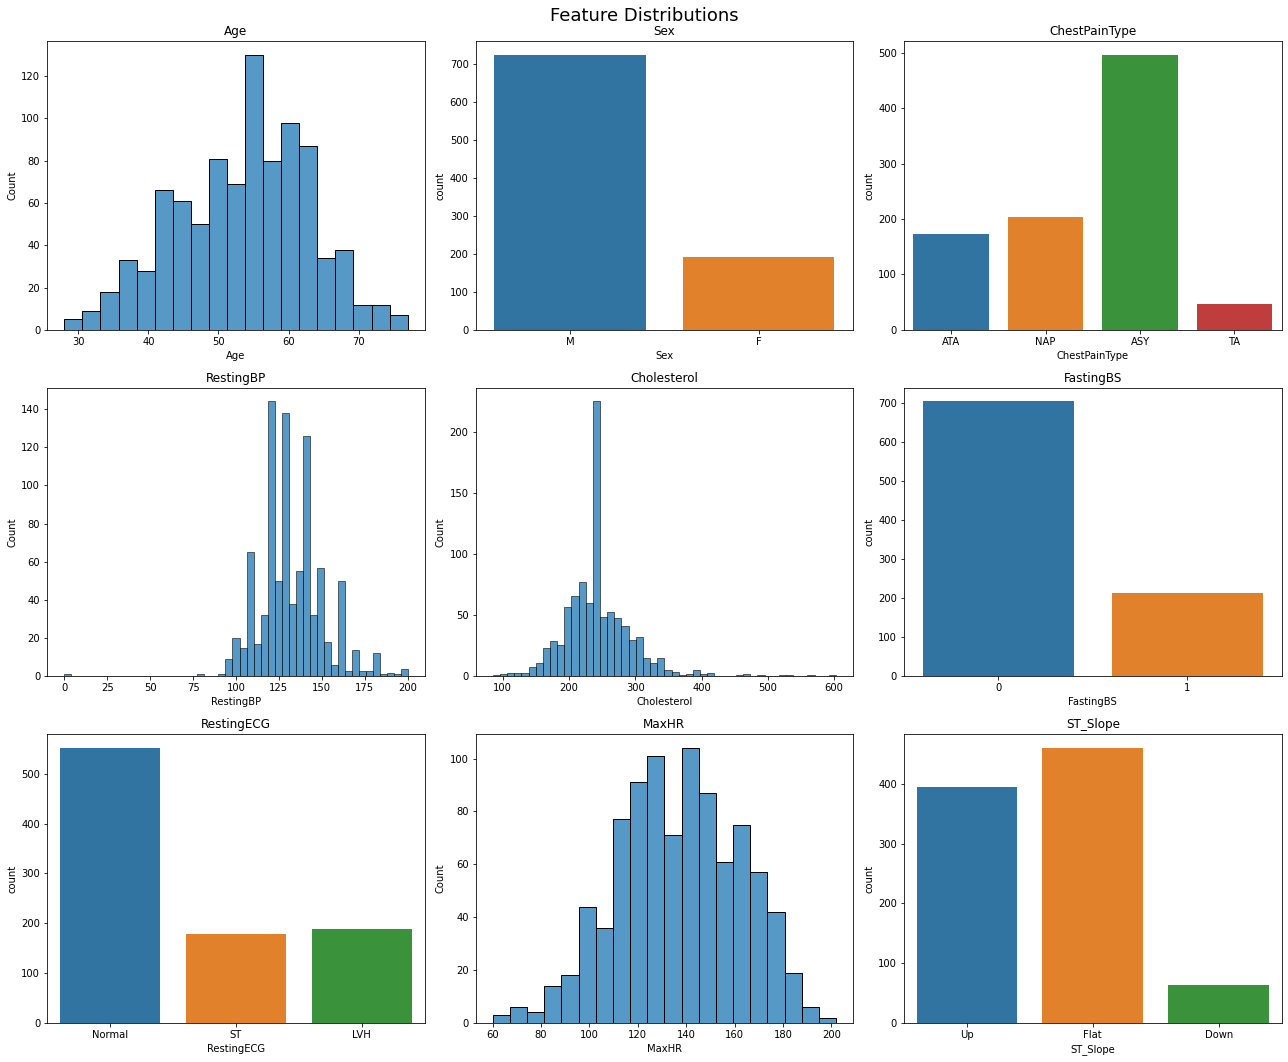

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle("Feature Distributions", fontsize=18)

sns.histplot(x=datasets["Age"],            ax=axes[0,0]).set_title("Age")
sns.countplot(data=datasets, x="Sex",      ax=axes[0,1]).set_title("Sex")
sns.countplot(x=datasets["ChestPainType"], ax=axes[0,2]).set_title("ChestPainType")
sns.histplot(x=datasets["RestingBP"],      ax=axes[1,0]).set_title("RestingBP")
sns.histplot(x=datasets["Cholesterol"],    ax=axes[1,1]).set_title("Cholesterol")
sns.countplot(x=datasets["FastingBS"],     ax=axes[1,2]).set_title("FastingBS")
sns.countplot(x=datasets["RestingECG"],    ax=axes[2,0]).set_title("RestingECG")
sns.histplot(x=datasets["MaxHR"],          ax=axes[2,1]).set_title("MaxHR")
sns.countplot(x=datasets["ST_Slope"],      ax=axes[2,2]).set_title("ST_Slope")

plt.tight_layout()
plt.show()

## 5. 심장질환 상관 확인

1. Slope와 HeartDisease(Target)의 관계 확인
2. Colesterol과 HeartDisease(Target)의 관계 확인)

- v1에서는 0(정상)의 경우 콜레스테롤이 더 높았지만 v2(수정본)에서는 1(심장질환)의 경우 더 높은 경우로 분석됨.

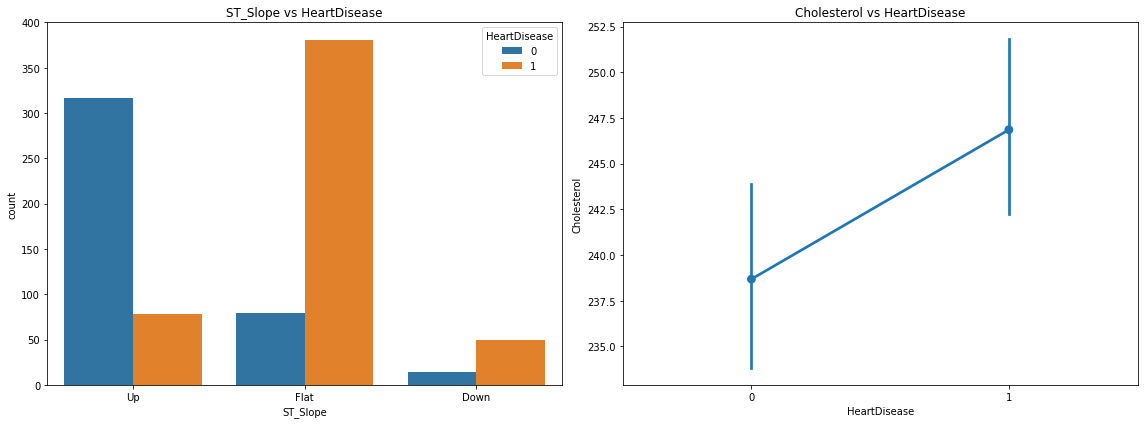

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(data=datasets, x="ST_Slope", hue="HeartDisease", ax=axes[0]).set_title("ST_Slope vs HeartDisease")
sns.pointplot(data=datasets, x="HeartDisease", y="Cholesterol", ax=axes[1]).set_title("Cholesterol vs HeartDisease")
plt.tight_layout()
plt.show()

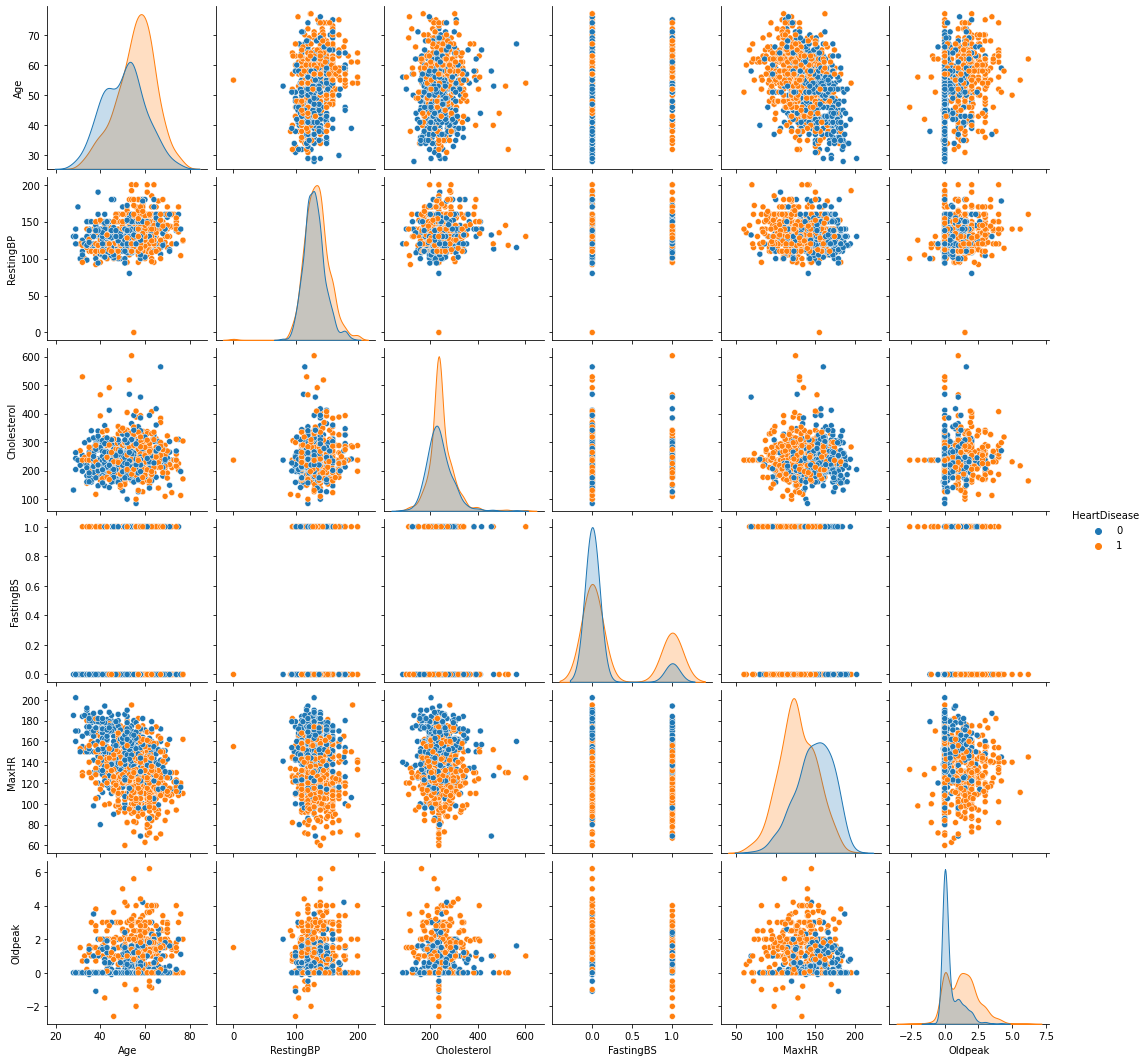

In [12]:
sns.pairplot(datasets, hue="HeartDisease")
plt.show()

## 6. 데이터 전처리

In [13]:
# ExerciseAngina: Y/N → True/False
datasets.ExerciseAngina = datasets.ExerciseAngina == "Y"

# Sex: M/F → True/False, 컬럼명 변경
# 열이름을 남성으로 바꿔 True면 남성 False면 여성으로 구분할 수 있게 전처리
datasets.Sex = datasets.Sex == "M"
datasets.rename(columns={"Sex": "Male"}, inplace=True)

# True/False의 열 이름을 형변환(정수) 하여 1, 0으로 확인
# Male --> 1(남자), 0(여자)
# ExerciseAngina --> (1) 운동으로 발생된 협심증 있음 (0) 없음
datasets['Male'] = datasets['Male'].astype(int)
datasets['ExerciseAngina'] = datasets['ExerciseAngina'].astype(int)

# 범주형 변수 원-핫 인코딩 (ChestPainType, RestingECG, ST_Slope)
datasets = pd.get_dummies(datasets)

In [14]:
# 타겟과 상관관계 확인
datasets.corr()["HeartDisease"].sort_values(ascending=False)

HeartDisease         1.000000
ST_Slope_Flat        0.554134
ChestPainType_ASY    0.516716
ExerciseAngina       0.494282
Oldpeak              0.403951
Male                 0.305445
Age                  0.282039
FastingBS            0.267291
ST_Slope_Down        0.122527
RestingBP            0.107589
RestingECG_ST        0.102527
Cholesterol          0.076114
RestingECG_LVH       0.010670
ChestPainType_TA    -0.054790
RestingECG_Normal   -0.091580
ChestPainType_NAP   -0.212964
MaxHR               -0.400421
ChestPainType_ATA   -0.401924
ST_Slope_Up         -0.622164
Name: HeartDisease, dtype: float64

In [15]:
# 상관관계 낮은 특성 제거
datasets = datasets.drop(columns=[
    "RestingBP", "RestingECG_ST", "Cholesterol",
    "RestingECG_LVH", "ChestPainType_TA", "RestingECG_Normal"

])
print("최종 특성 수:", datasets.shape[1])
datasets.head()

#    "RestingECG_LVH", "ChestPainType_TA", "Cholesterol"
    #"RestingECG_Normal", "RestingECG_ST", "RestingBP",

최종 특성 수: 13


,Age,Male,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,0,172,0,0.0,0,0,1,0,0,0,1
1,49,0,0,156,0,1.0,1,0,0,1,0,1,0
2,37,1,0,98,0,0.0,0,0,1,0,0,0,1
3,48,0,0,108,1,1.5,1,1,0,0,0,1,0
4,54,1,0,122,0,0.0,0,0,0,1,0,0,1


## 7. 모델링 (XGBoost)

In [16]:
X = datasets.drop(columns="HeartDisease") # Train
y = datasets["HeartDisease"] # Target

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = xgb.XGBClassifier(random_state=7,
                          eval_metric='logloss',
                          use_label_encoder= False,)
    
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, [round(v) for v in y_pred])
print(f"Test Accuracy (SMOTE 적용 전): {accuracy * 100:.2f}%")

Test Accuracy (SMOTE 적용 전): 81.52%


## 8. SMOTETomek 오버샘플링

In [17]:
smote = SMOTETomek(random_state=42)
X_train_over, y_train_over = smote.fit_resample(x_train, y_train)

print(f"SMOTE 적용 전 훈련 데이터: {x_train.shape}")
print(f"SMOTE 적용 후 훈련 데이터: {X_train_over.shape}")
print(f"\nSMOTE 전  - Class 1: {sum(y_train==1)}, Class 0: {sum(y_train==0)}")
print(f"SMOTE 후  - Class 1: {sum(y_train_over==1)}, Class 0: {sum(y_train_over==0)}")

SMOTE 적용 전 훈련 데이터: (734, 12)
SMOTE 적용 후 훈련 데이터: (716, 12)

SMOTE 전  - Class 1: 401, Class 0: 333
SMOTE 후  - Class 1: 358, Class 0: 358


In [18]:
model.fit(X_train_over, y_train_over)

y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, [round(v) for v in y_pred])
print(f"Test Accuracy (SMOTE 적용 후): {accuracy * 100:.2f}%")

Test Accuracy (SMOTE 적용 후): 79.89%


## 9. K-Fold 교차검증 (5-Fold) --> SMOTE

[Before SMOTE]
  Fold 1: 0.8707
  Fold 2: 0.8571
  Fold 3: 0.7959
  Fold 4: 0.8571
  Fold 5: 0.8151
  Mean: 0.8392


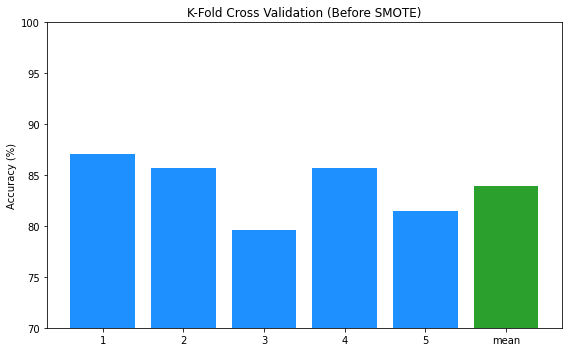


[After SMOTE]
  Fold 1: 0.8503
  Fold 2: 0.8367
  Fold 3: 0.8095
  Fold 4: 0.8912
  Fold 5: 0.8082
  Mean: 0.8392


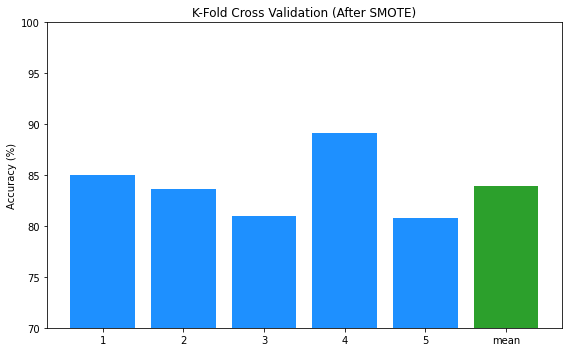


정확도 변화: 83.92% → 83.92%


In [19]:
from sklearn.base import clone
from imblearn.over_sampling import SMOTE

def run_kfold(features, labels, title, base_model, apply_smote=False):
    skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_accuracy = []

    for fold, (train_idx, val_idx) in enumerate(skfold.split(features, labels), 1):
        X_tr, X_val = features.iloc[train_idx], features.iloc[val_idx]
        y_tr, y_val = labels.iloc[train_idx], labels.iloc[val_idx]

        # SMOTE는 fold 안에서만 (data leakage 방지)
        if apply_smote:
            sm = SMOTE(random_state=42)
            X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

        fold_model = clone(base_model)
        fold_model.fit(X_tr, y_tr)

        # 검증은 원본 데이터로
        acc = round(accuracy_score(y_val, fold_model.predict(X_val)), 4)
        print(f"  Fold {fold}: {acc:.4f}")
        cv_accuracy.append(acc)

    mean_acc = np.mean(cv_accuracy)
    print(f"  Mean: {mean_acc:.4f}")

    values = [v * 100 for v in cv_accuracy] + [mean_acc * 100]
    colors = ["dodgerblue"] * 5 + ["C2"]

    plt.figure(figsize=(8, 5))
    plt.bar(range(6), values, color=colors)
    plt.xticks(range(6), ["1", "2", "3", "4", "5", "mean"])
    plt.ylabel("Accuracy (%)")
    plt.ylim(70, 100)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return mean_acc

# 실행
print("[Before SMOTE]")
before_acc = run_kfold(
    x_train, y_train,
    "K-Fold Cross Validation (Before SMOTE)",
    base_model=model,
    apply_smote=False
)

print("\n[After SMOTE]")
after_acc = run_kfold(
    x_train, y_train,          # 원본 데이터 그대로 넘김
    "K-Fold Cross Validation (After SMOTE)",
    base_model=model,
    apply_smote=True           # fold 안에서 SMOTE 적용
)

print(f"\n정확도 변화: {before_acc*100:.2f}% → {after_acc*100:.2f}%")

## 10. K-Fold 교차검증 (5-Fold) --> SMOTETomek

[Before SMOTE]
  Fold 1: 0.8707
  Fold 2: 0.8571
  Fold 3: 0.7959
  Fold 4: 0.8571
  Fold 5: 0.8151
  Mean: 0.8392


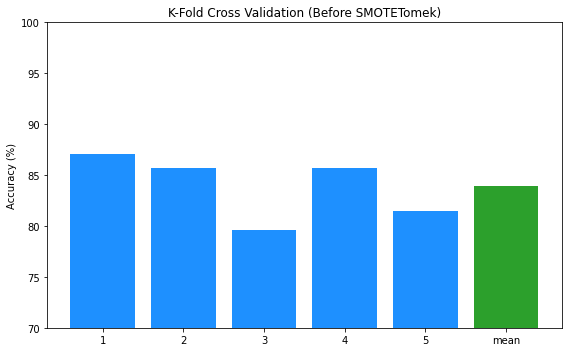


[After SMOTE]
  Fold 1: 0.8503
  Fold 2: 0.8299
  Fold 3: 0.8231
  Fold 4: 0.8844
  Fold 5: 0.8562
  Mean: 0.8488


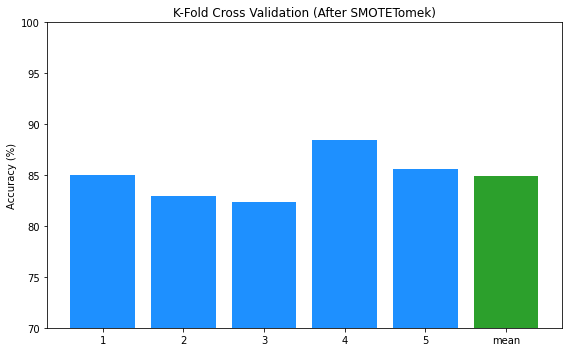


정확도 변화: 83.92% → 84.88%


In [21]:
from sklearn.base import clone
from imblearn.over_sampling import SMOTE

def run_kfold(features, labels, title, base_model, apply_smote=False):
    skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_accuracy = []

    for fold, (train_idx, val_idx) in enumerate(skfold.split(features, labels), 1):
        X_tr, X_val = features.iloc[train_idx], features.iloc[val_idx]
        y_tr, y_val = labels.iloc[train_idx], labels.iloc[val_idx]

        # 증강은 fold 안에서만 (data leakage 방지)
        if apply_smote:
            sm = SMOTETomek(random_state=42)
            X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

        fold_model = clone(base_model)
        fold_model.fit(X_tr, y_tr)

        # 검증은 원본 데이터로
        acc = round(accuracy_score(y_val, fold_model.predict(X_val)), 4)
        print(f"  Fold {fold}: {acc:.4f}")
        cv_accuracy.append(acc)

    mean_acc = np.mean(cv_accuracy)
    print(f"  Mean: {mean_acc:.4f}")

    values = [v * 100 for v in cv_accuracy] + [mean_acc * 100]
    colors = ["dodgerblue"] * 5 + ["C2"]

    plt.figure(figsize=(8, 5))
    plt.bar(range(6), values, color=colors)
    plt.xticks(range(6), ["1", "2", "3", "4", "5", "mean"])
    plt.ylabel("Accuracy (%)")
    plt.ylim(70, 100)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return mean_acc

# 실행
print("[Before SMOTE]")
before_acc = run_kfold(
    x_train, y_train,
    "K-Fold Cross Validation (Before SMOTETomek)",
    base_model=model,
    apply_smote=False
)

print("\n[After SMOTE]")
after_acc = run_kfold(
    x_train, y_train,          # 원본 데이터 그대로 넘김
    "K-Fold Cross Validation (After SMOTETomek)",
    base_model=model,
    apply_smote=True           # fold 안에서 SMOTETomek 적용
)

print(f"\n정확도 변화: {before_acc*100:.2f}% → {after_acc*100:.2f}%")

[Before SMOTETomek]
  Fold 1: 0.8707
  Fold 2: 0.8571
  Fold 3: 0.7959
  Fold 4: 0.8571
  Fold 5: 0.8151
  Mean: 0.8392
  Std : 0.0286


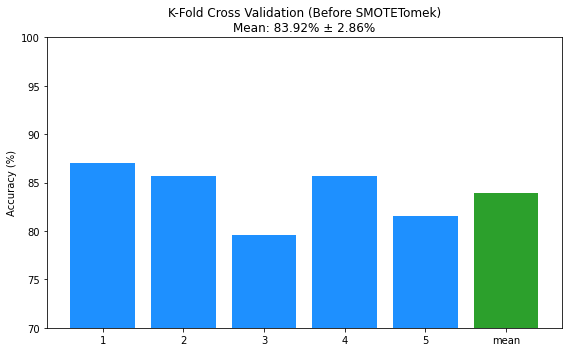


[After SMOTETomek]
  Fold 1: 0.8503
  Fold 2: 0.8299
  Fold 3: 0.8231
  Fold 4: 0.8844
  Fold 5: 0.8562
  Mean: 0.8488
  Std : 0.0216


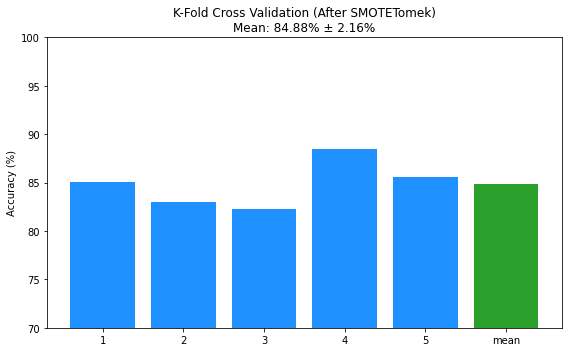


정확도 변화: 83.92% ± 2.86%
           → 84.88% ± 2.16%


In [22]:
from sklearn.base import clone
from imblearn.combine import SMOTETomek
import numpy as np

def run_kfold(features, labels, title, base_model, apply_smote=False):
    skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_accuracy = []

    for fold, (train_idx, val_idx) in enumerate(skfold.split(features, labels), 1):
        X_tr, X_val = features.iloc[train_idx], features.iloc[val_idx]
        y_tr, y_val = labels.iloc[train_idx], labels.iloc[val_idx]

        if apply_smote:
            sm = SMOTETomek(random_state=42)
            X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

        fold_model = clone(base_model)
        fold_model.fit(X_tr, y_tr)

        acc = round(accuracy_score(y_val, fold_model.predict(X_val)), 4)
        print(f"  Fold {fold}: {acc:.4f}")
        cv_accuracy.append(acc)

    mean_acc = np.mean(cv_accuracy)
    std_acc = np.std(cv_accuracy)   # 표준편차 추가

    print(f"  Mean: {mean_acc:.4f}")
    print(f"  Std : {std_acc:.4f}")  # 표준편차 출력

    values = [v * 100 for v in cv_accuracy] + [mean_acc * 100]
    colors = ["dodgerblue"] * 5 + ["C2"]

    plt.figure(figsize=(8, 5))
    plt.bar(range(6), values, color=colors)
    plt.xticks(range(6), ["1", "2", "3", "4", "5", "mean"])
    plt.ylabel("Accuracy (%)")
    plt.ylim(70, 100)
    # 제목에 mean ± std 같이 표시
    plt.title(f"{title}\nMean: {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")
    plt.tight_layout()
    plt.show()

    return mean_acc, std_acc   # 둘 다 반환

# 실행
print("[Before SMOTETomek]")
before_acc, before_std = run_kfold(
    x_train, y_train,
    "K-Fold Cross Validation (Before SMOTETomek)",
    base_model=model,
    apply_smote=False
)

print("\n[After SMOTETomek]")
after_acc, after_std = run_kfold(
    x_train, y_train,
    "K-Fold Cross Validation (After SMOTETomek)",
    base_model=model,
    apply_smote=True
)

print(f"\n정확도 변화: {before_acc*100:.2f}% ± {before_std*100:.2f}%")
print(f"           → {after_acc*100:.2f}% ± {after_std*100:.2f}%")

## 11. XAI 분석 - SHAP

> **핵심**: SHAP 분석은 **테스트 데이터** 기준으로 수행합니다.  

In [23]:
# SHAP 분석용 최종 모델 (전체 데이터 SMOTE 후 학습)
sm_final = SMOTETomek(random_state=42)
X_train_over, y_train_over = sm_final.fit_resample(x_train, y_train)
model.fit(X_train_over, y_train_over)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              eval_metric='logloss', gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.300000012,
              max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=8,
              num_parallel_tree=1, predictor='auto', random_state=7,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', use_label_encoder=False,
              validate_parameters=1, verbosity=None)

In [24]:
# 테스트 데이터 인덱스 초기화
x_test_r = x_test.reset_index(drop=True)
y_test_r = y_test.reset_index(drop=True)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_test_r)  # ← 테스트 데이터 사용

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (184, 12)


ntree_limit is deprecated, use `iteration_range` or model slicing instead.


In [25]:
# 예측 결과 기반으로 대표 환자 선택
y_pred_test = model.predict(x_test_r)
Person1 = int(np.where(y_pred_test == 1)[0][0])  # 심장질환 예측
Person2 = int(np.where(y_pred_test == 0)[0][0])  # 정상 예측

print(f"Person1: index={Person1}, 실제={y_test_r[Person1]}, 예측={y_pred_test[Person1]}")
print(f"Person2: index={Person2}, 실제={y_test_r[Person2]}, 예측={y_pred_test[Person2]}")

Person1: index=1, 실제=1, 예측=1
Person2: index=0, 실제=0, 예측=0


### Force Plot - 개별 환자 해석

- **Force Plot**: 각 특성이 예측값을 기준값(base value) 대비 얼마나 올리거나 내리는지 표현
- 빨간색(→): 심장질환 예측 방향으로 기여
- 파란색(←): 정상 예측 방향으로 기여

In [36]:
# Person1 - 심장질환 예측 환자
print(f"--- Person1 (index={Person1}) ---")
print(f"모델 예측 : {y_pred_test[Person1]}, 실제 값 {y_test_r[Person1]}")
print("-----------데이터 feature 정보------------")
display(x_test_r.iloc[Person1])
print("------------------------------")

shap.force_plot(explainer.expected_value, shap_values[Person1, :], x_test_r.iloc[Person1, :])

--- Person1 (index=1) ---
모델 예측 : 1, 실제 값 1
-----------데이터 feature 정보------------


Age                   53.0
Male                   1.0
FastingBS              0.0
MaxHR                130.0
ExerciseAngina         0.0
Oldpeak                0.0
ChestPainType_ASY      0.0
ChestPainType_ATA      0.0
ChestPainType_NAP      1.0
ST_Slope_Down          0.0
ST_Slope_Flat          1.0
ST_Slope_Up            0.0
Name: 1, dtype: float64

------------------------------


##### 결과분석
- ST분절이 평평하면서(Flat=1), 상승하지않았다(Up=0)의 결과는 심장 활동이 정상적으로 회복하는 경향이 낮음을 나타낼 수 있음.

In [37]:
# Person2 - 정상 예측 환자

print(f"--- Person1 (index={Person2}) ---")
print(f"모델 예측 : {y_pred_test[Person2]}, 실제 값 {y_test_r[Person2]}")
print("-----------데이터 feature 정보------------")
display(x_test_r.iloc[Person2])
print("------------------------------")

shap.force_plot(explainer.expected_value, shap_values[Person2, :], x_test_r.iloc[Person2, :])

--- Person1 (index=0) ---
모델 예측 : 0, 실제 값 0
-----------데이터 feature 정보------------


Age                   63.0
Male                   0.0
FastingBS              0.0
MaxHR                179.0
ExerciseAngina         0.0
Oldpeak                0.0
ChestPainType_ASY      0.0
ChestPainType_ATA      1.0
ChestPainType_NAP      0.0
ST_Slope_Down          0.0
ST_Slope_Flat          0.0
ST_Slope_Up            1.0
Name: 0, dtype: float64

------------------------------


##### 결과분석
- ST분절이 평평하지않고(Flat=0), 상승했다(Up=1)의 결과는 심장 활동이 정상적으로 회복하는데 방해받지 않음을 나타낼 수 있음.
- 위의 person1 case와 비교하였을 때 Age의 경우 +10살로, 고령의 나이는 심장질환에 영향을 미침.

### Summary Plot - 전체 특성 중요도

- **Bar plot**: 각 특성의 평균 |SHAP| 값 → 전체적인 중요도 순위
- **Beeswarm plot**: 특성값(색상)이 예측에 미치는 방향과 크기를 동시에 표현

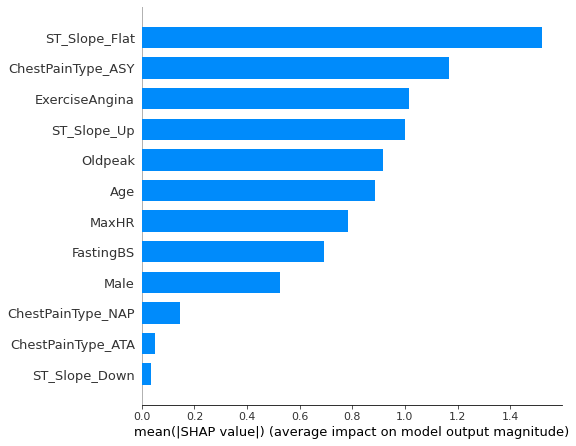

In [28]:
# 특성 중요도 (Bar)
"""
상위 4개의 important feature = ST_Slope_Flat, ChestPainType_ASY, ExerciseAngina, ST_Slope_Up
"""
shap.summary_plot(shap_values, x_test_r, plot_type="bar")

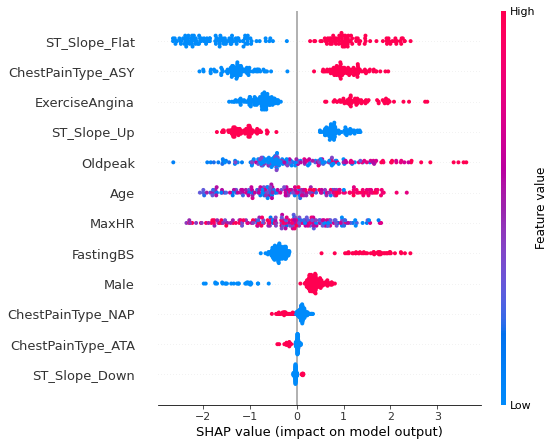

In [29]:
# Beeswarm - 특성값과 SHAP값 분포
shap.summary_plot(shap_values, x_test_r)

- ST분절 관련 피처(Flat, Up)가 1, 4위를 차지하며 심장질환 예측의 핵심 지표임이 확인됐습니다.
- 특히 ST_Slope_Flat과 ST_Slope_Up이 서로 반대 방향으로 작용하는 패턴은 의학적으로도 완벽히 일치하며, 모델이 임상적으로 의미 있는 패턴을 학습했음을 보여줍니다.   

--> 따라서 ***심장질환 분류는 심전도에서 파생된 특징이 가장 크게 영향을 주는 것을 확인하였습니다.***

In [56]:
# 전체 데이터 Force Plot
# (90도 회전해서 보면 개별 force plot들의 집합)
shap.force_plot(explainer.expected_value, shap_values, x_test_r)

### Dependence Plot - 주요 특성 상세 분석

- x축: 특성값, y축: 해당 특성의 SHAP값
- 특성값이 변함에 따라 예측에 미치는 영향이 어떻게 달라지는지 확인

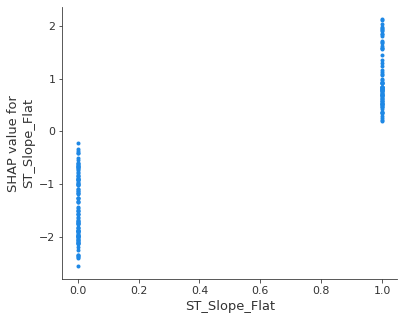

In [57]:
shap.dependence_plot("ST_Slope_Flat",      shap_values, x_test_r, interaction_index=None)

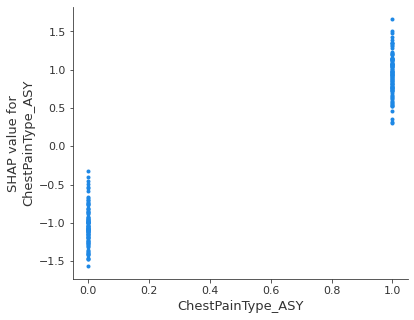

In [58]:
shap.dependence_plot("ChestPainType_ASY", shap_values, x_test_r, interaction_index=None)

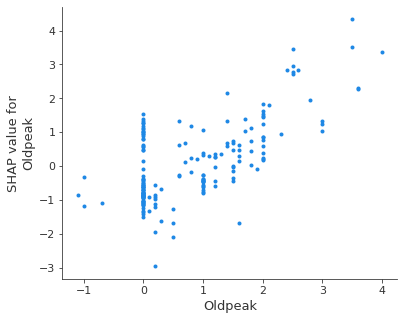

In [59]:
shap.dependence_plot("Oldpeak",          shap_values, x_test_r, interaction_index=None)

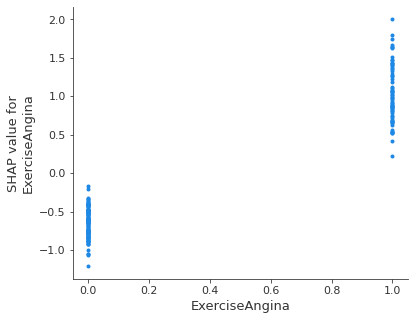

In [60]:
shap.dependence_plot("ExerciseAngina",     shap_values, x_test_r, interaction_index=None)

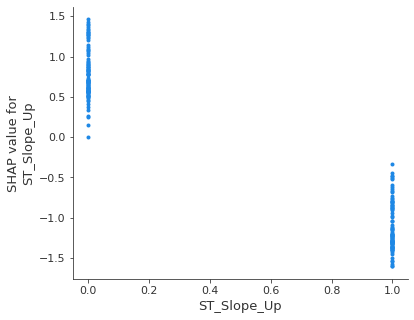

In [61]:
shap.dependence_plot("ST_Slope_Up",        shap_values, x_test_r, interaction_index=None)